<a href="https://colab.research.google.com/github/grace-mariya/Data-Ai-Journey/blob/main/Classification_Excercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Loan Approval Prediction**

In [998]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [999]:
df = pd.read_csv('/content/LoanApprovalPrediction.csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [1000]:
df.isna().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [1001]:
df.shape

(614, 13)

In [1002]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [1003]:
df=df.drop(columns=['Loan_ID'])


In [1004]:
df['Gender'].value_counts()

,count
Gender,
Male,489
Female,112


In [1005]:
df['Married'].value_counts()

,count
Married,
Yes,398
No,213


In [1006]:
df['Dependents'].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,50
3,1


In [1007]:
df['Self_Employed'].value_counts()

,count
Self_Employed,
No,500
Yes,82


In [1008]:
df['LoanAmount'].unique()

array([ nan, 128.,  66., 120., 141., 267.,  95., 158., 168., 349.,  70.,
       109., 200., 114.,  17., 125., 100.,  76., 133., 115., 104., 315.,
       116., 112., 151., 191., 122., 110.,  35., 201.,  74., 106., 320.,
       144., 184.,  80.,  47.,  75., 134.,  96.,  88.,  44., 286.,  97.,
       135., 180.,  99., 165., 258., 126., 312., 136., 172.,  81., 187.,
       113., 176., 130., 111., 167., 265.,  50., 210., 175., 131., 188.,
        25., 137., 160., 225., 216.,  94., 139., 152., 118., 185., 154.,
        85., 259., 194.,  93., 370., 182., 650., 102., 290.,  84., 242.,
       129.,  30., 244., 600., 255.,  98., 275., 121.,  63., 700.,  87.,
       101., 495.,  67.,  73., 260., 108.,  58.,  48., 164., 170.,  83.,
        90., 166., 124.,  55.,  59., 127., 214., 240.,  72.,  60., 138.,
        42., 280., 140., 155., 123., 279., 192., 304., 330., 150., 207.,
       436.,  78.,  54.,  89., 143., 105., 132., 480.,  56., 159., 300.,
       376., 117.,  71., 490., 173.,  46., 228., 30

In [1009]:
df['Loan_Amount_Term'].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [1010]:
df['Credit_History'].unique()

array([ 1.,  0., nan])

Handling Missing Values

In [1011]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

In [1012]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].mode()[0])


In [1013]:
df['Dependents'] = df['Dependents'].replace('3+','4')
df['Dependents'] = df['Dependents'].astype(int)

After Handling Missing values

In [1014]:
df.isna().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


Correlation Matrix

In [1015]:
corr = df.corr(numeric_only=True)
corr

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
Dependents,1.000000,0.135002,0.034477,0.170895,-0.104738,-0.044069
ApplicantIncome,0.135002,1.000000,-0.116605,0.565181,-0.046531,-0.018615
CoapplicantIncome,0.034477,-0.116605,1.000000,0.189218,-0.059383,0.011134
LoanAmount,0.170895,0.565181,0.189218,1.000000,0.036960,-0.000607
Loan_Amount_Term,-0.104738,-0.046531,-0.059383,0.036960,1.000000,-0.004705
Credit_History,-0.044069,-0.018615,0.011134,-0.000607,-0.004705,1.000000


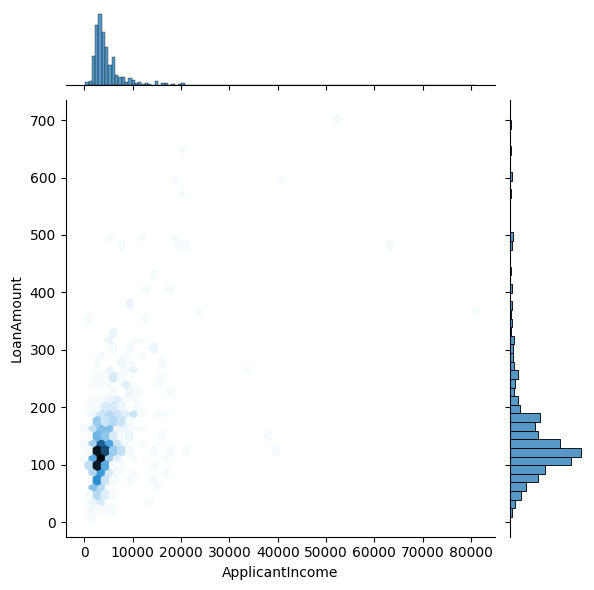

In [1016]:
sns.jointplot(x='ApplicantIncome', y='LoanAmount',data=df,kind='hex')
plt.show()

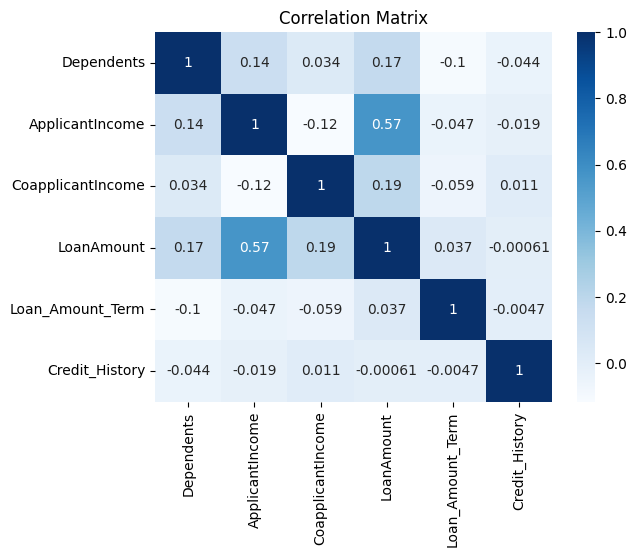

In [1017]:
sns.heatmap(corr,annot=True,cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

In [1018]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,4,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [1019]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [1020]:
df.tail()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,4,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


Label Encoding

In [1021]:
from sklearn.preprocessing import LabelEncoder
lab = LabelEncoder()

In [1022]:
df['Gender'] = lab.fit_transform(df['Gender'])
df['Married'] = lab.fit_transform(df['Married'])
df['Education'] = lab.fit_transform(df['Education'])
df['Self_Employed'] = lab.fit_transform(df['Self_Employed'])
df['Property_Area'] = lab.fit_transform(df['Property_Area'])
df['Loan_Status'] = lab.fit_transform(df['Loan_Status'])

In [1023]:
features = list(zip(df['Gender'],df['Married'],df['Education'],df['Self_Employed'],df['Property_Area']))
features

[(1, 0, 0, 0, 2),
 (1, 1, 0, 0, 0),
 (1, 1, 0, 1, 2),
 (1, 1, 1, 0, 2),
 (1, 0, 0, 0, 2),
 (1, 1, 0, 1, 2),
 (1, 1, 1, 0, 2),
 (1, 1, 0, 0, 1),
 (1, 1, 0, 0, 2),
 (1, 1, 0, 0, 1),
 (1, 1, 0, 0, 2),
 (1, 1, 0, 0, 2),
 (1, 1, 0, 0, 2),
 (1, 0, 0, 0, 0),
 (1, 1, 0, 0, 2),
 (1, 0, 0, 0, 2),
 (1, 0, 1, 0, 2),
 (0, 0, 0, 0, 2),
 (1, 1, 1, 0, 0),
 (1, 1, 0, 0, 2),
 (1, 1, 1, 0, 2),
 (1, 1, 0, 0, 2),
 (1, 1, 1, 0, 1),
 (1, 1, 1, 0, 0),
 (1, 1, 0, 0, 1),
 (1, 1, 0, 1, 1),
 (1, 1, 0, 0, 1),
 (1, 1, 1, 0, 2),
 (1, 0, 1, 0, 2),
 (0, 0, 0, 0, 1),
 (1, 1, 0, 0, 2),
 (1, 0, 0, 0, 2),
 (1, 0, 0, 1, 0),
 (1, 1, 0, 0, 1),
 (1, 0, 0, 0, 0),
 (1, 1, 0, 0, 2),
 (1, 1, 0, 0, 2),
 (0, 1, 0, 0, 1),
 (1, 0, 0, 0, 2),
 (1, 0, 1, 0, 1),
 (1, 0, 0, 0, 2),
 (1, 0, 0, 0, 2),
 (1, 1, 0, 0, 2),
 (1, 1, 0, 0, 1),
 (1, 1, 1, 1, 2),
 (0, 0, 0, 0, 2),
 (1, 1, 0, 0, 2),
 (1, 1, 0, 0, 2),
 (0, 1, 0, 0, 2),
 (0, 0, 0, 0, 1),
 (0, 1, 1, 0, 1),
 (0, 0, 0, 0, 1),
 (0, 0, 0, 0, 1),
 (1, 1, 0, 0, 2),
 (0, 1, 0, 1, 2),
 (1, 1, 0,

Feature Selection

In [1024]:
x = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']


In [1025]:
from sklearn.model_selection import train_test_split

In [1026]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [1027]:
from sklearn.preprocessing import StandardScaler

In [1028]:
scaler = StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)


KNN Algorithm

In [1029]:
from sklearn.neighbors import KNeighborsClassifier

In [1030]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train,y_train)


KNeighborsClassifier(n_neighbors=7)

In [1031]:
y_pred = knn.predict(x_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [1032]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [1033]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[18, 25],
       [ 2, 78]])

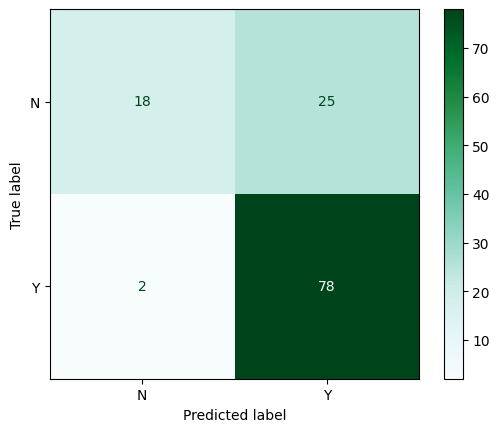

In [1034]:
labels = ['N','Y']
cmd = ConfusionMatrixDisplay(cm,display_labels=labels)
cmd.plot(cmap=plt.cm.BuGn)

In [1035]:
from sklearn.metrics import accuracy_score

In [1036]:
ac = accuracy_score(y_test,y_pred)
ac

0.7804878048780488

Naive Bayes Algorithm

In [1037]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,0,1
610,1,1,4,0,0,4106,0.0,40.0,180.0,1.0,0,1
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,2,1
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,2,1


In [1038]:
from sklearn.naive_bayes import GaussianNB

In [1039]:
gnb = GaussianNB()
gnb.fit(x_train,y_train)

GaussianNB()

In [1040]:
g_y_pred = gnb.predict(x_test)
g_y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [1041]:
g_cm = confusion_matrix(y_test,g_y_pred)
g_cm

array([[18, 25],
       [ 2, 78]])

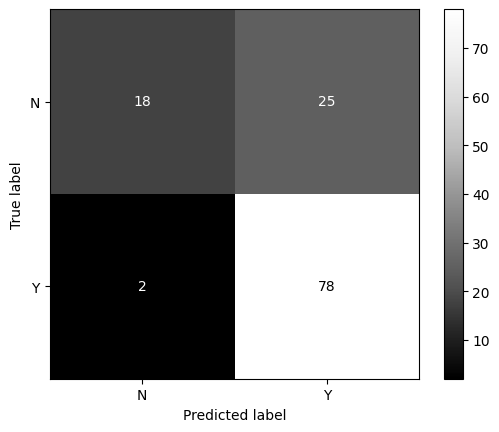

In [1042]:
g_cmd = ConfusionMatrixDisplay(g_cm,display_labels=labels)
g_cmd.plot(cmap=plt.cm.Greys_r)

In [1043]:
g_ac = accuracy_score(y_test,g_y_pred)
g_ac

0.7804878048780488